In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# BASEL'S PROBLEM

# set the truncation point N

N = 1e8

def basel(n):
    return np.float32(1) / np.float32(n**2)

arr_sing = np.arange(1,N+1)
arr_sing = np.float32(1) / np.float32(arr_sing**2)

sum_sing_norm = np.sum(arr_sing)
sum_sing_rev = np.sum(np.flip(arr_sing))

SUM_TRUE_SING = np.float32(np.pi**2 / 6)

print(f'Sum in single precision, analitic:        {SUM_TRUE_SING}')

print(f'Sum in single precision, normal ord.:     {sum_sing_norm}')
print(f'Sum in single precision, reverse ord.:    {sum_sing_rev}')


Sum in single precision, analitic:        1.644934058189392
Sum in single precision, normal ord.:     1.6449337005615234
Sum in single precision, reverse ord.:    1.644933819770813


In [3]:
N_OD_max = 8
N_range = np.logspace(3, N_OD_max, 50)

Ls_sing_norm = []
Ls_sing_rev = []

for N in N_range:
    arr_sing = np.arange(1,N+1)
    arr_sing = np.float32(1) / np.float32(arr_sing**2)

    Ls_sing_norm.append(np.sum(arr_sing))
    Ls_sing_rev.append(np.sum(np.flip(arr_sing)))

Np_sing_norm = np.array(Ls_sing_norm)
Np_sing_rev = np.array(Ls_sing_rev)

Np_sing_norm_ERR = abs(Np_sing_norm - SUM_TRUE_SING)
Np_sing_rev_ERR = abs(Np_sing_rev - SUM_TRUE_SING)


Sum in single precision, analitic: 1.6449340668482264


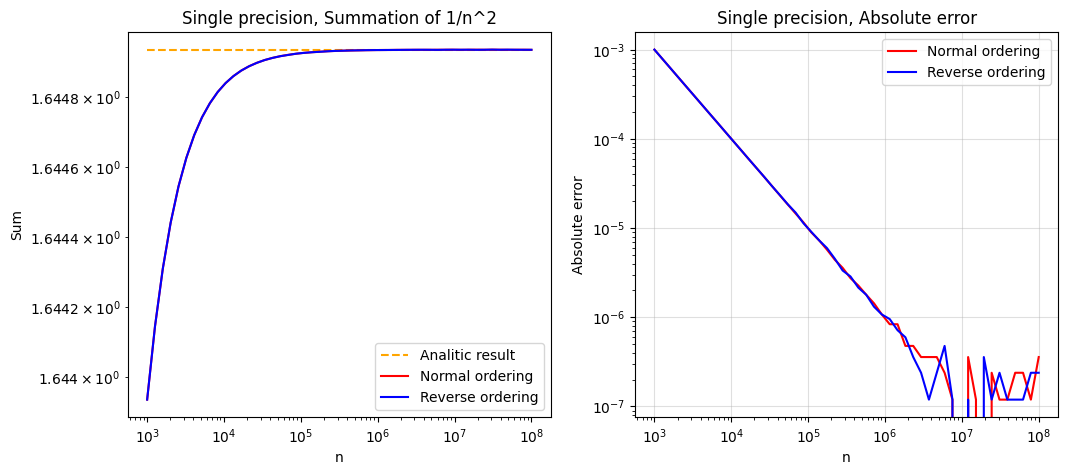

In [10]:

print(f'Sum in single precision, analitic: {np.pi**2 / 6}')

# ------- PLOTTING -------

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].set_title('Single precision, Summation of 1/n^2')
ax[0].hlines(SUM_TRUE_SING, min(N_range), max(N_range), ls='--', colors='orange', label='Analitic result')
ax[0].plot(N_range, Np_sing_norm, color='red', label='Normal ordering')
ax[0].plot(N_range, Np_sing_rev, color='blue', label='Reverse ordering')
ax[0].set_xlabel('n')
ax[0].set_ylabel('Sum')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].legend()
ax[1].grid(alpha=0.4)


ax[1].set_title('Single precision, Absolute error')
ax[1].plot(N_range, Np_sing_norm_ERR, color='red', label='Normal ordering')
ax[1].plot(N_range, Np_sing_rev_ERR, color='blue', label='Reverse ordering')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Absolute error')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].legend()
ax[1].grid(alpha=0.4)

plt.show()
